# 2. EDA and Analysis (Interrupted Time Series and Gross Profit Analysis)
Pre-modelling exploratory analysis of `feature_engineered_data.csv`.  
Covers parallel-trends validation, outlier checks, promo-window verification, and general purchase patterns.

**Promo windows**
- **Promo 1** (Gallons only / 20% discount): Dec 5 – Dec 31 2025  
- **Promo 2** (All paint / 20% discount): Feb 7 – Feb 17 2026

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})

df = pd.read_csv('../data/feature_engineered_data.csv', parse_dates=['Date'])

PROMO_WINDOWS = [
    ('Promo 1\n(Gallons, Dec)', pd.Timestamp('2025-12-05'), pd.Timestamp('2025-12-31')),
    ('Promo 2\n(All paint, Feb)', pd.Timestamp('2026-02-07'), pd.Timestamp('2026-02-17')),
]

print(f"Rows: {len(df):,}   |   Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print("\nSize counts:", df['Size'].value_counts().to_dict())
print("Is_Promo_1 rows:", df['Is_Promo_1'].sum(), "  Is_Promo_2 rows:", df['Is_Promo_2'].sum())
df.head(3)

Rows: 2,718   |   Date range: 2025-06-23 → 2026-02-19

Size counts: {'Gallon': 1459, 'Half Pint': 598, 'Quart': 544, '5 Gallon': 117}
Is_Promo_1 rows: 6   Is_Promo_2 rows: 32


,Date,Year,Month,Day,Day of the Week,Customer Name,Customer Type,Item No,Product Name,Size,...,Total Sale Price,Standard Cost,Retail Price,Contractor 1 Price,Contractor 2 Price,Contractor 3 Price,Discount_Pct,Is_Promo_1,Is_Promo_2,Is_Promo
0,2026-02-19,2026,2,19,Thursday,KL Creation,Contractor 1,F5241X-001,1G F5241X AURA EG INT,Gallon,...,104.77,59.10,116.86000,104.770000,96.710000,89.660000,0.0,0,0,0
1,2026-02-19,2026,2,19,Thursday,KL Creation,Contractor 1,F5081X-001,1G F5081X WB CEILING PNT BASE 1,Gallon,...,73.85,42.58,86.15945,73.846687,68.721756,60.828571,-0.0,0,0,0
2,2026-02-19,2026,2,19,Thursday,"Grieve, Carolyn",Retail Selling Price,K5521X-001,1G K5521X REGAL SLCT MA INT,Gallon,...,96.70,49.06,96.70000,83.600000,77.560000,68.490000,0.0,0,0,0



## Parallel Trends Check
 Gallons (Treatment) vs Control (Quarts + Half Pints + 5 Gallon, Sundries).
Three views: full 8-month span, pre promo 1, and 7 day average for 8-month span

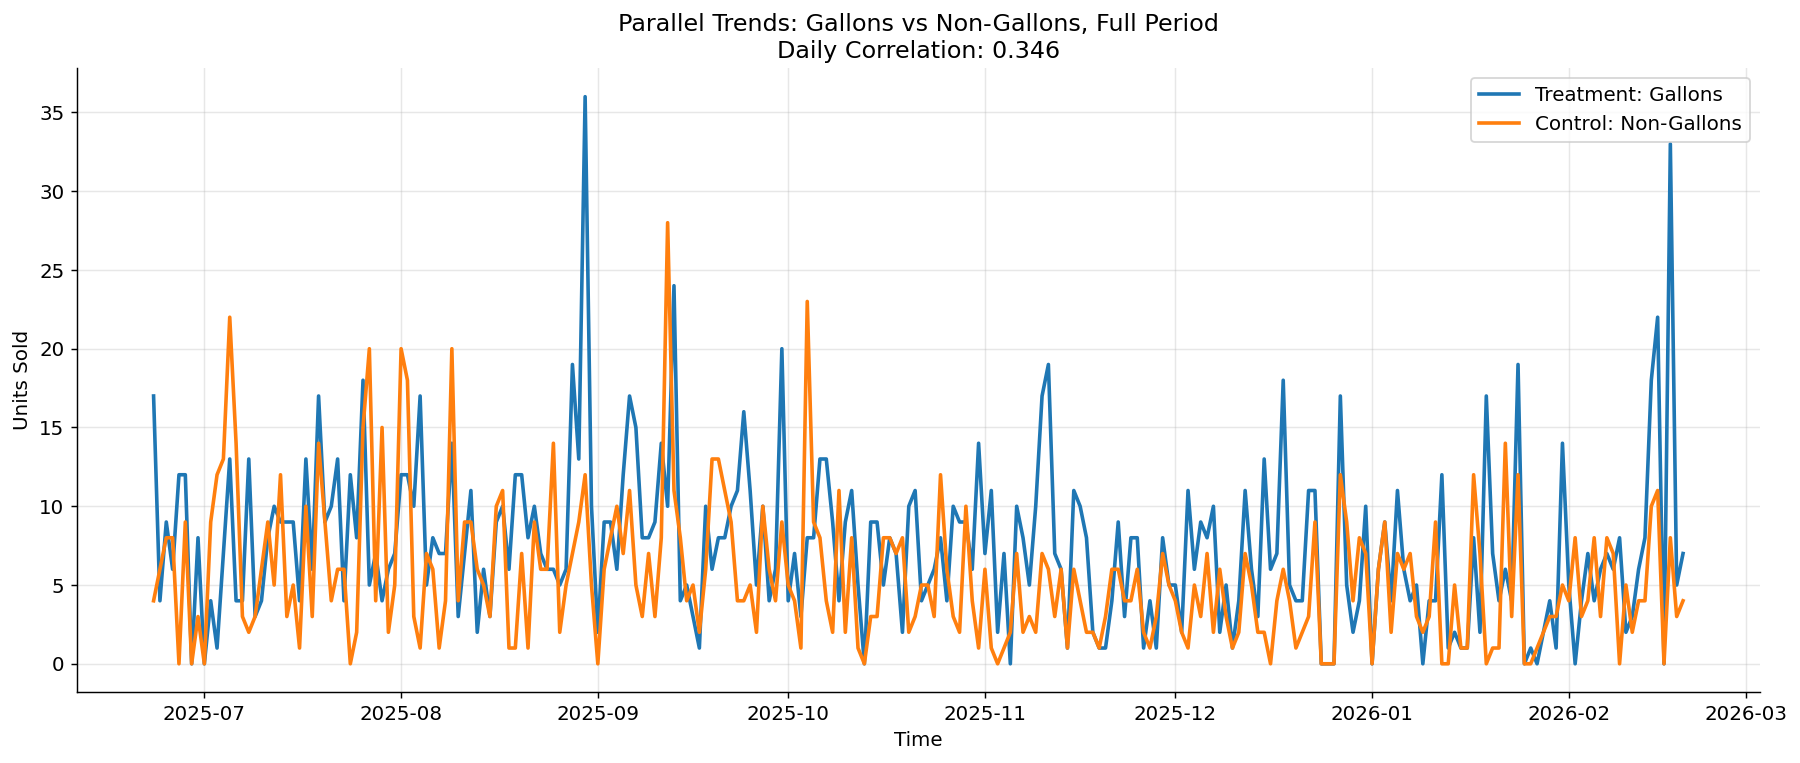

Parallel Trends: Gallons vs Non-Gallons, Full Period correlation: 0.346


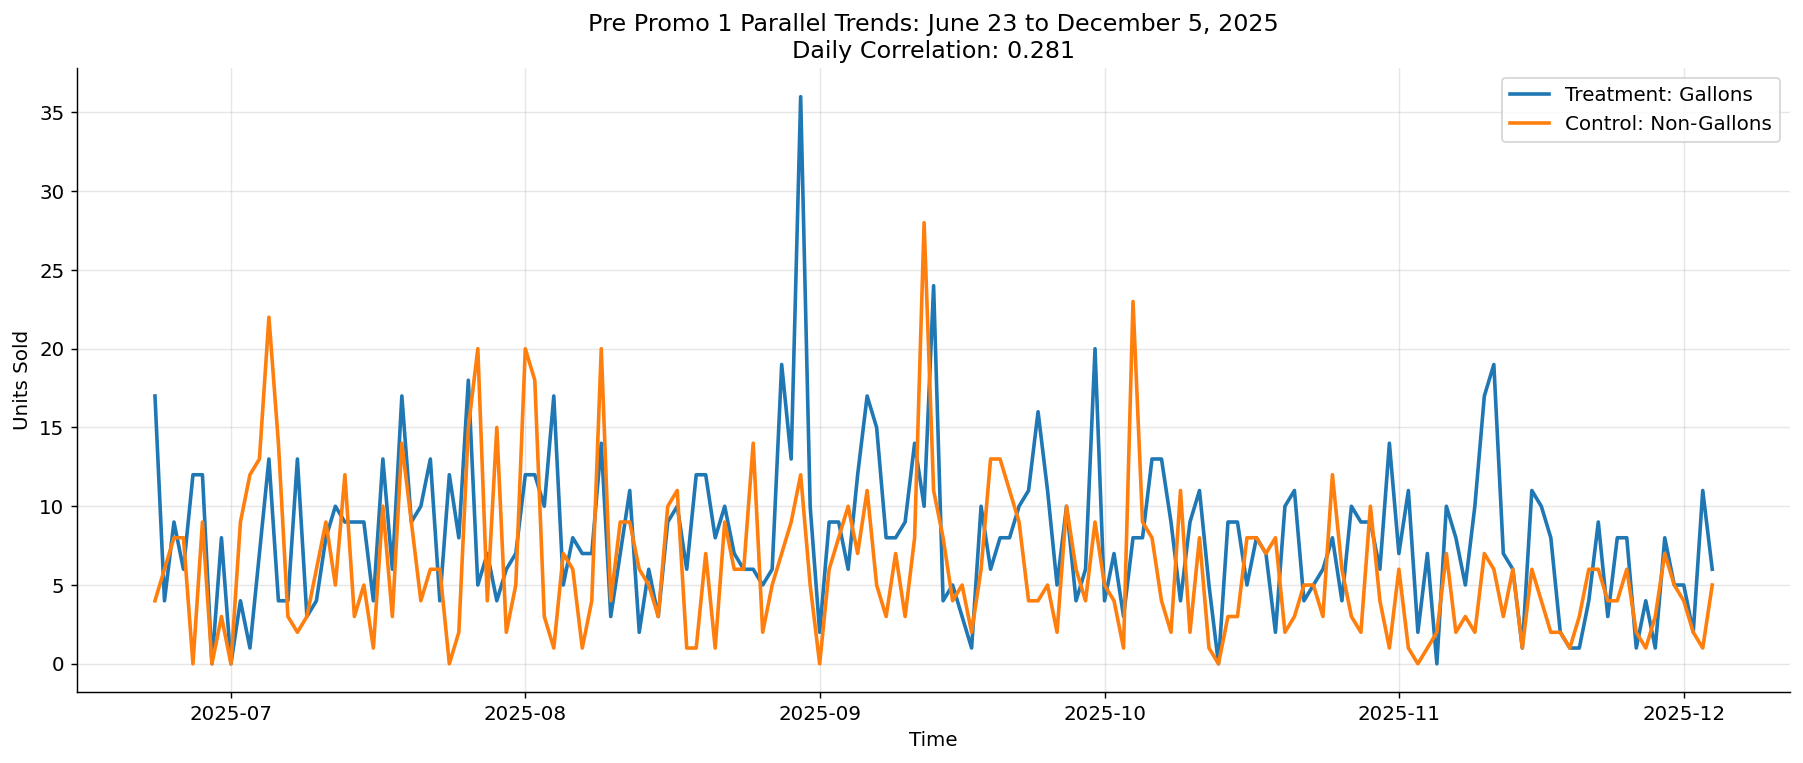

Pre Promo 1 Parallel Trends: June 23 to December 5, 2025 correlation: 0.281


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/feature_engineered_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Define treatment/control groups
df["Group"] = df["Size"].eq("Gallon").map({
    True: "Treatment: Gallons",
    False: "Control: Non-Gallons"
})

daily = (
    df.groupby(["Date", "Group"])["Quantity"]
      .sum()
      .unstack(fill_value=0)
      .sort_index()
)

daily = daily.asfreq("D", fill_value=0)

def plot_parallel_trends(data, title):
    corr = data["Treatment: Gallons"].corr(data["Control: Non-Gallons"])

    plt.figure(figsize=(14, 6))

    plt.plot(
        data.index,
        data["Treatment: Gallons"],
        label="Treatment: Gallons",
        linewidth=2
    )

    plt.plot(
        data.index,
        data["Control: Non-Gallons"],
        label="Control: Non-Gallons",
        linewidth=2
    )

    plt.title(f"{title}\nDaily Correlation: {corr:.3f}")
    plt.xlabel("Time")
    plt.ylabel("Units Sold")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"{title} correlation:", round(corr, 3))


# All 8 months / full available dataset
plot_parallel_trends(
    daily,
    "Parallel Trends: Gallons vs Non-Gallons, Full Period"
)


# Pre Promo 1: June 23, 2025 to December 5, 2025
pre_promo_1 = daily.loc["2025-06-23":"2025-12-04"]

plot_parallel_trends(
    pre_promo_1,
    "Pre Promo 1 Parallel Trends: June 23 to December 5, 2025"
)

This cell runs the raw daily parallel trends check across the full 8-month period and also isolated to the pre-promo 1 window. The parallel trends assumption is the core requirement for Difference-in-Differences to be valid. The idea is that if Gallons and Non-Gallons move together before the promotion, then any divergence during the promo window can be attributed to the promotion itself rather than unrelated factors. The daily correlation printed on each chart is the key number to look at. If the groups do not track each other, there is no basis for using Non-Gallons as a counterfactual for what Gallon sales would have been without the promotion.

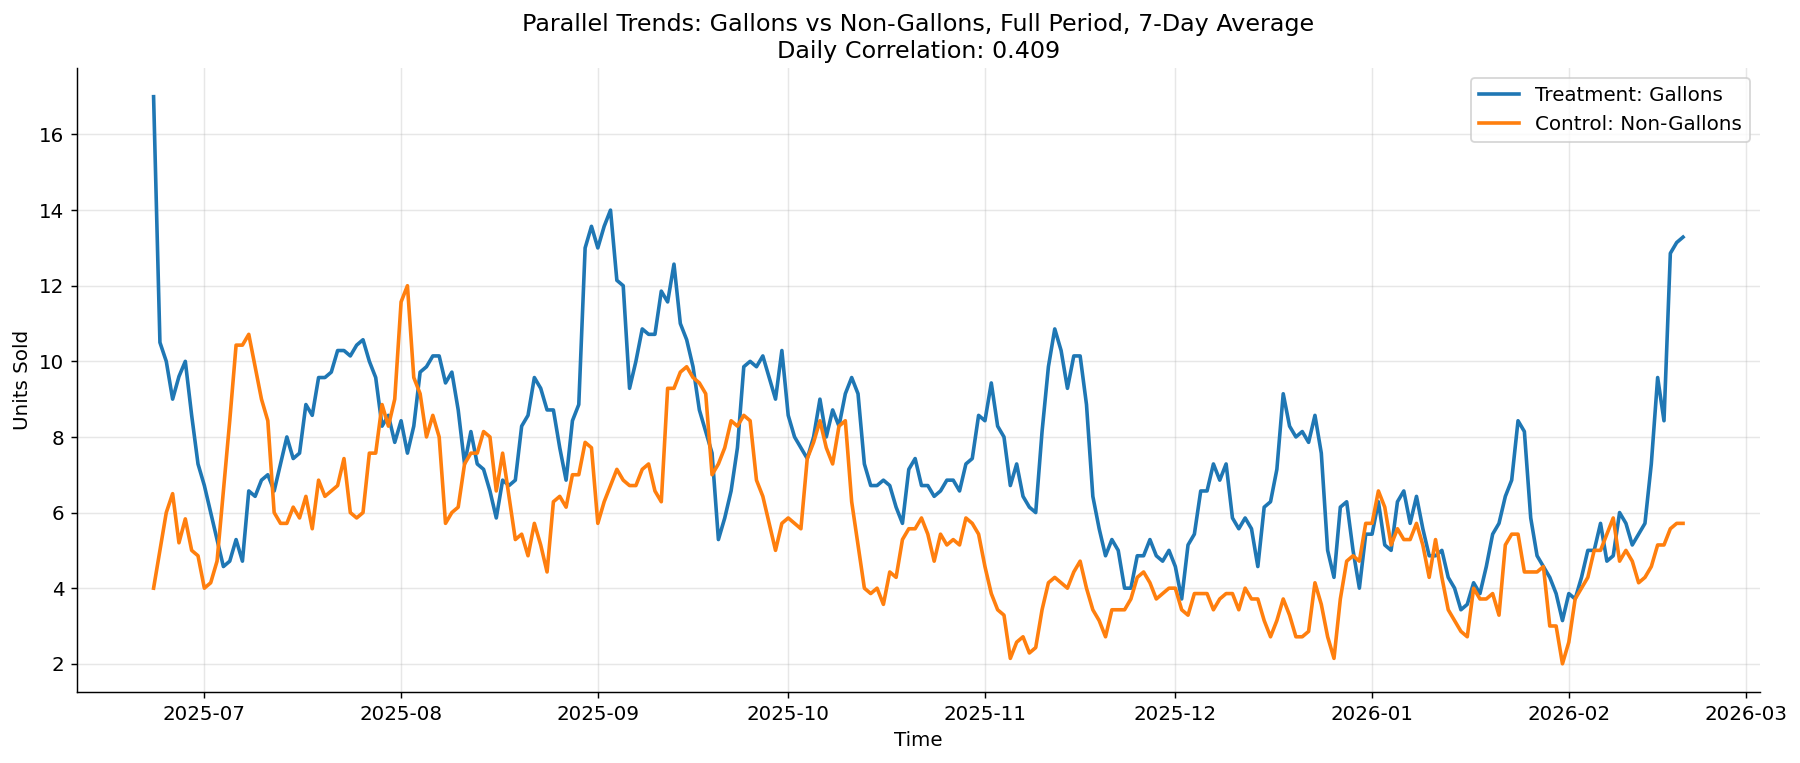

Parallel Trends: Gallons vs Non-Gallons, Full Period, 7-Day Average correlation: 0.409


In [32]:
daily_7d = daily.rolling(7, min_periods=1).mean()

plot_parallel_trends(
    daily_7d,
    "Parallel Trends: Gallons vs Non-Gallons, Full Period, 7-Day Average"
)

pre_promo_1_7d = daily_7d.loc["2025-06-23":"2025-12-05"]

All three views (full period raw, pre-promo raw, and 7-day rolling average) show near-zero correlation between Gallons and Non-Gallons. The 7-day smoothed version was added to rule out the possibility that day-to-day noise was masking an underlying relationship, but even after smoothing the two series move independently of each other. This makes intuitive sense when I think about who is buying each size. Gallons are almost exclusively purchased by contractors restocking inventory for large jobs, while smaller sizes are bought by retail customers for touch-ups and smaller projects. These are two completely different demand signals responding to different things, so there is no reason to expect them to move together. Because the parallel trends assumption fails here, Difference-in-Differences does not show promise for this dataset.

## Correlation Matrix (Pre-Promo 1)

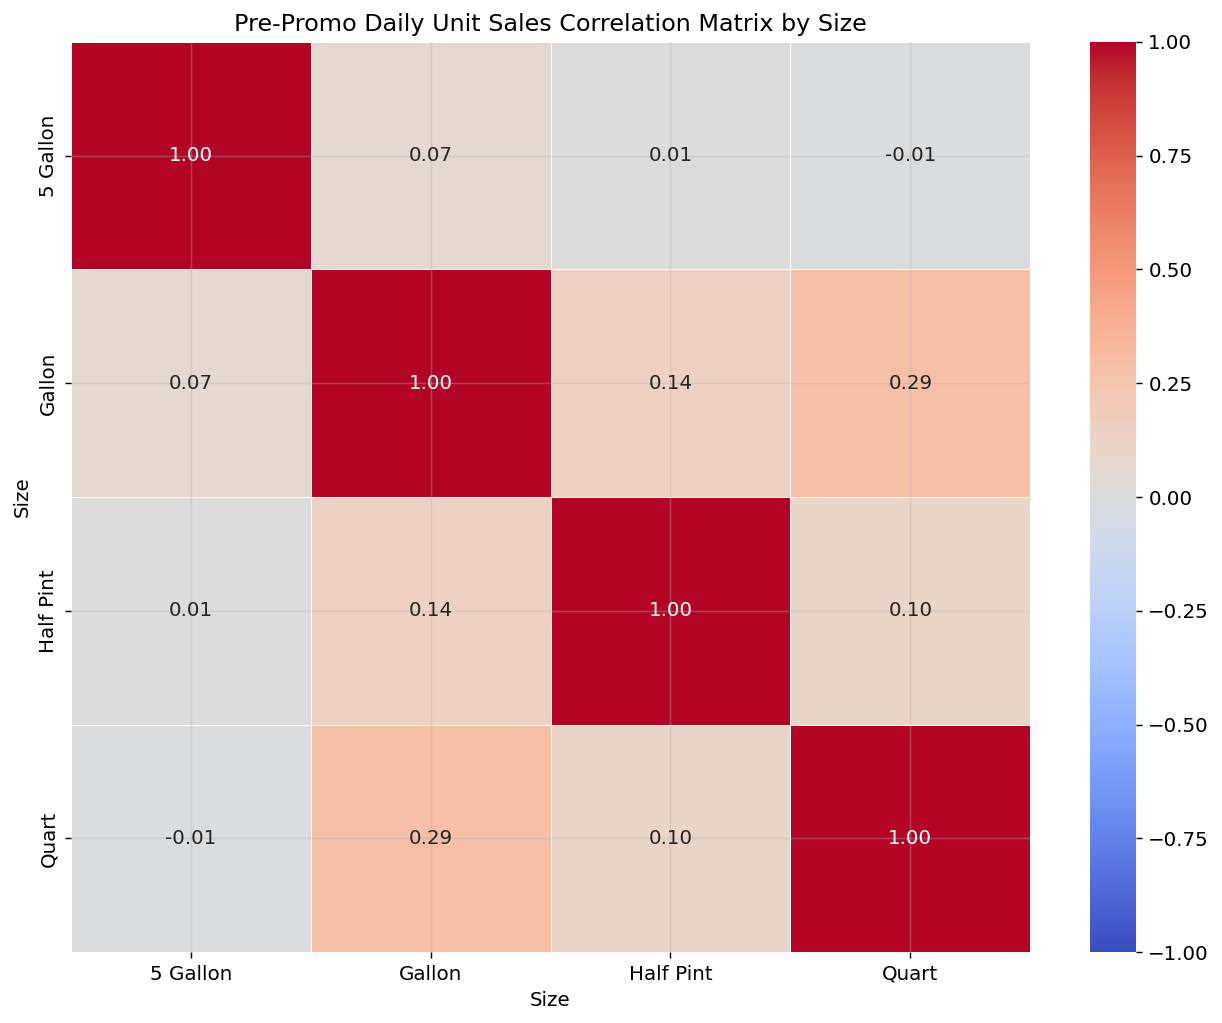

Correlation with Gallon during pre-promo period:
Size
Quart        0.285105
Half Pint    0.136720
5 Gallon     0.065649
Name: Gallon, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use only pre-promo period for choosing a control group
# Promo 1 starts on Dec 5, 2025
pre_promo = df[
    (df["Date"] >= "2025-06-23") &
    (df["Date"] < "2025-12-05")
].copy()

# Daily unit sales by Size
daily_by_size = (
    pre_promo
    .groupby(["Date", "Size"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
    .asfreq("D", fill_value=0)
)

# Remove very low-volume categories that may create noisy correlations
min_total_units = 20
daily_by_size = daily_by_size.loc[:, daily_by_size.sum() >= min_total_units]

# Correlation matrix
corr_matrix = daily_by_size.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pre-Promo Daily Unit Sales Correlation Matrix by Size")
plt.tight_layout()
plt.show()

# Show correlations with Gallon, sorted
gallon_corrs = (
    corr_matrix["Gallon"]
    .drop("Gallon")
    .sort_values(ascending=False)
)

print("Correlation with Gallon during pre-promo period:")
print(gallon_corrs)

As a final effort for finding a DiD control group, a correlation matrix is used. It uses only the pre-promo period to avoid contaminating the correlation estimates with any effect from the promotions themselves. Even looking at every combination of paint sizes, none of them show a correlation with Gallons strong enough to act as a control. The strongest correlations in the matrix tend to be between Quarts and Half Pints, which makes sense since both are bought by a similar retail customer making small purchases, but neither of those correlates meaningfully with Gallons. This confirms that there is no subset of the data I can use as a control group for Difference-in-Differences. DiD requires a group that would have followed the same trajectory as Gallons in the absence of the promotion, and no such group exists here.


## Promo-Window Verification
Daily total units sold across the full ~8-month period (Jun 2025 – Feb 2026).  
**Yellow shading = promo date window.**  
Check: do sales spikes land inside the yellow band?

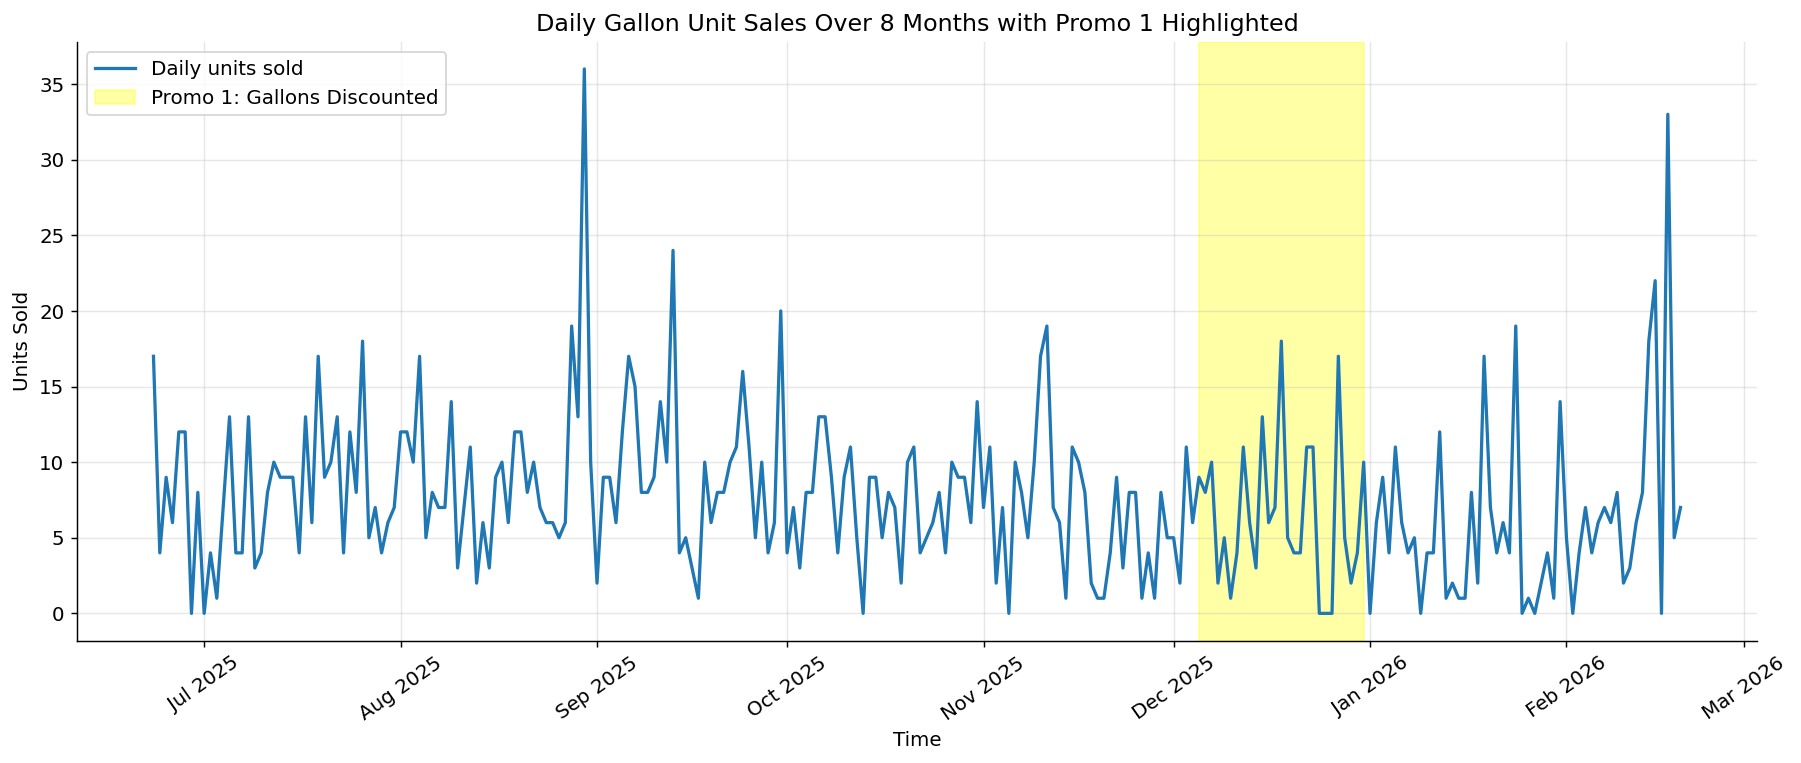

Daily Gallon Unit Sales Over 8 Months with Promo 1 Highlighted
Average daily units before promo: 8.10
Average daily units during promo: 6.52
During / before ratio: 0.80x


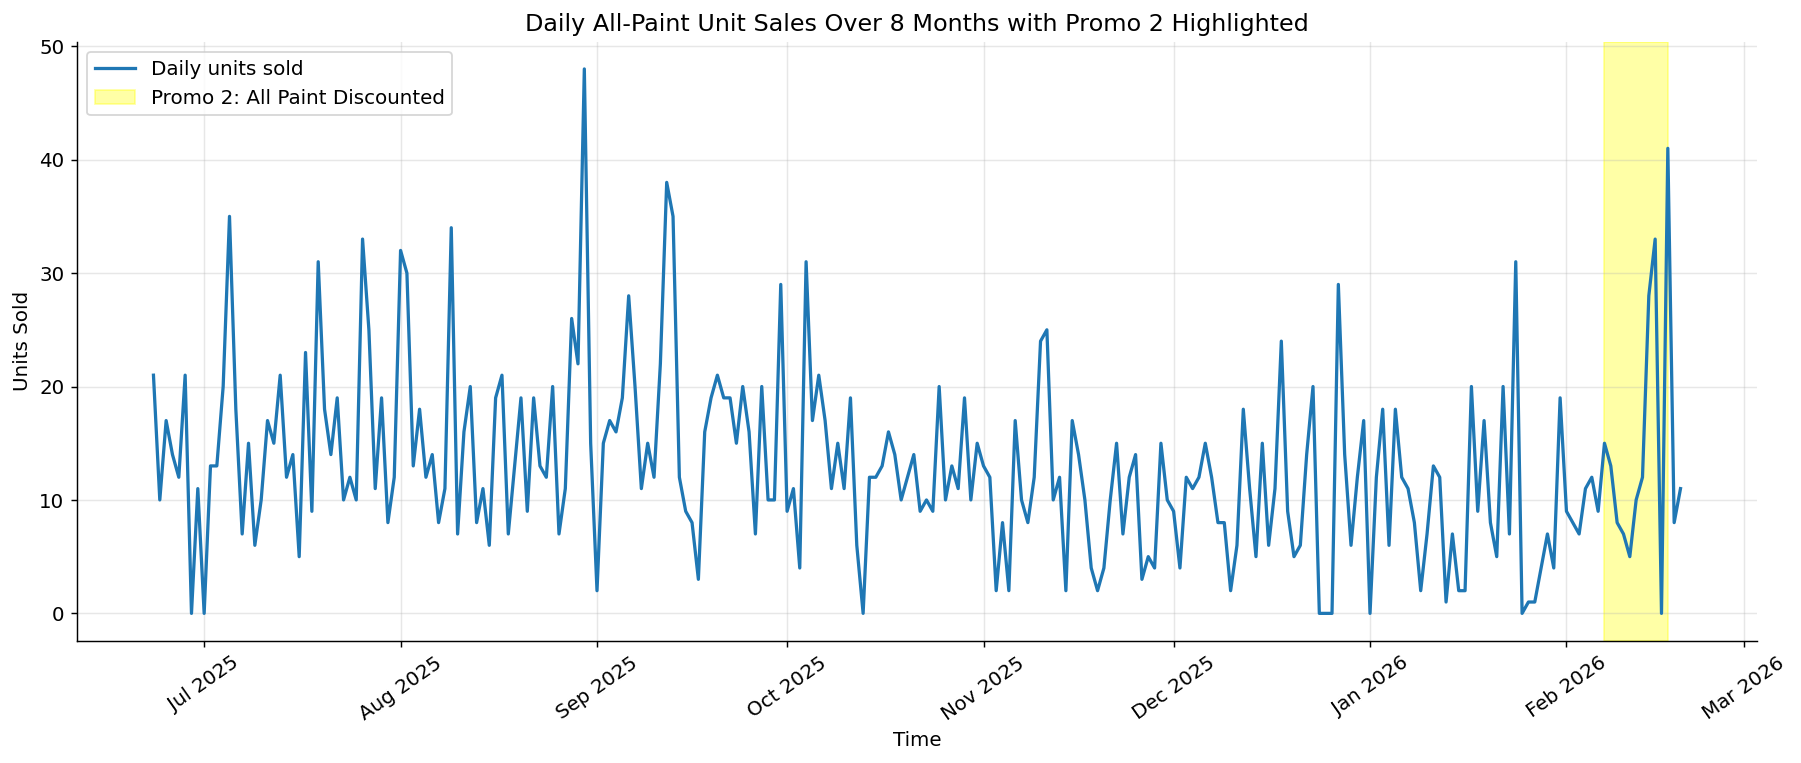

Daily All-Paint Unit Sales Over 8 Months with Promo 2 Highlighted
Average daily units before promo: 12.97
Average daily units during promo: 15.64
During / before ratio: 1.21x


In [ ]:
import matplotlib.dates as mdates

# Promo windows
PROMO_1_START = pd.Timestamp("2025-12-05")
PROMO_1_END = pd.Timestamp("2025-12-31")

PROMO_2_START = pd.Timestamp("2026-02-07")
PROMO_2_END = pd.Timestamp("2026-02-17")

# Daily gallons only
daily_gallons = (
    df[df["Size"] == "Gallon"]
    .groupby("Date")["Quantity"]
    .sum()
    .sort_index()
    .asfreq("D", fill_value=0)
)

# Daily all paint
paint_sizes = ["Gallon", "Quart", "5 Gallon", "Half Pint"]
daily_all_paint = (
    df[df["Size"].isin(paint_sizes)]
    .groupby("Date")["Quantity"]
    .sum()
    .sort_index()
    .asfreq("D", fill_value=0)
)

def plot_daily_sales(series, title, promo_start, promo_end, promo_label):
    plt.figure(figsize=(14, 6))

    plt.plot(
        series.index,
        series.values,
        linewidth=1.8,
        color="#1f77b4",
        label="Daily units sold"
    )

    plt.axvspan(
        promo_start,
        promo_end,
        color="yellow",
        alpha=0.35,
        label=promo_label
    )

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Units Sold")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=35)

    plt.tight_layout()
    plt.show()

    before = series.loc[:promo_start - pd.Timedelta(days=1)].mean()
    during = series.loc[promo_start:promo_end].mean()

    print(title)
    print(f"Average daily units before promo: {before:.2f}")
    print(f"Average daily units during promo: {during:.2f}")
    print(f"During / before ratio: {during / before:.2f}x")


plot_daily_sales(
    daily_gallons,
    "Daily Gallon Unit Sales Over 8 Months with Promo 1 Highlighted",
    PROMO_1_START,
    PROMO_1_END,
    "Promo 1: Gallons Discounted"
)

plot_daily_sales(
    daily_all_paint,
    "Daily All-Paint Unit Sales Over 8 Months with Promo 2 Highlighted",
    PROMO_2_START,
    PROMO_2_END,
    "Promo 2: All Paint Discounted"
)

These charts overlay the promo windows in yellow on top of the actual daily unit sales. The main purpose is to visually verify that the promo flags I created in notebook 1 land in the right place. For Promo 1, the gallon sales chart shows no obvious spike during December and in fact the average during the promo window is lower than the period before it. For Promo 2, the all-paint chart shows a modest lift with a during/before ratio of about 1.21x. The critical thing to understand here is that this raw before/after comparison does not tell me whether the promotions actually worked as December is inherently a slow period for paint. The relevant question is not "did December sales go up?" but "were December sales higher than they would have been if there had been no promotion?" That is exactly what the ITS model below is designed to answer by projecting a counterfactual baseline from the pre-promo trend.


## Day-of-Week Purchase Patterns
Are there structural weekday / weekend effects that DiD must account for?

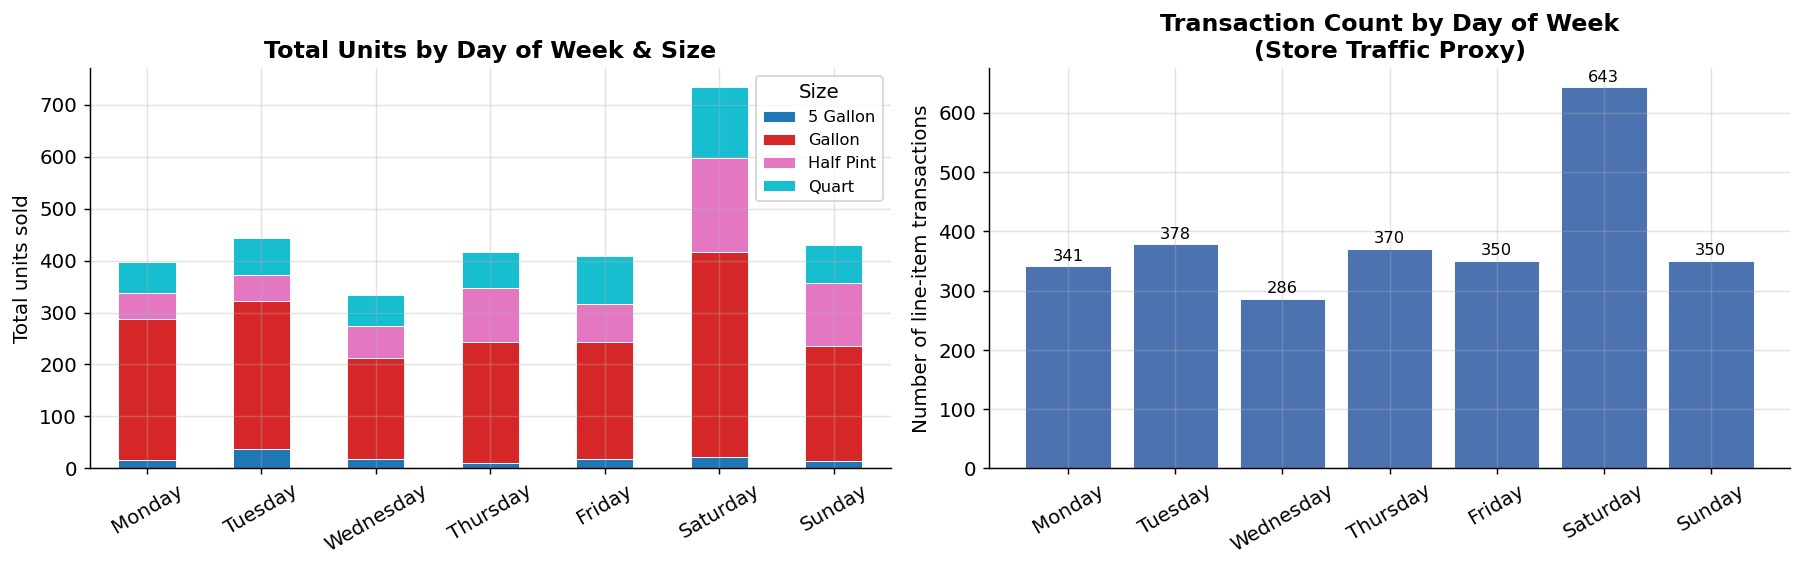

In [5]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Day of the Week'] = pd.Categorical(df['Day of the Week'], categories=dow_order, ordered=True)

# Average daily quantity by day-of-week, by Size
dow_size = (df.groupby(['Day of the Week','Size'])['Quantity'].sum()
            .unstack('Size').fillna(0))

# Transaction count by day-of-week (store traffic proxy)
dow_txn  = df.groupby('Day of the Week').size().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Stacked bar — total units by size & day
ax = axes[0]
dow_size.reindex(dow_order).plot(kind='bar', stacked=True, ax=ax,
                                  colormap='tab10', edgecolor='white', linewidth=0.5)
ax.set_xlabel('')
ax.set_ylabel('Total units sold')
ax.set_title('Total Units by Day of Week & Size', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Size', fontsize=9)

# Transaction count (foot traffic)
ax = axes[1]
bars = ax.bar(dow_txn.index, dow_txn.values, color='#4C72B0', edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, dow_txn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('Number of line-item transactions')
ax.set_title('Transaction Count by Day of Week\n(Store Traffic Proxy)', fontweight='bold')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

The two charts show total units sold and transaction count broken down by day of the week across the full dataset. The reason I looked at this is that day-of-week effects are a common confounder in retail sales analysis. If certain days consistently see higher sales, the ITS regression model needs to control for that explicitly. Without a day-of-week control, the model might partially attribute a high-sales Monday to the promotion if the promo window happened to start on a Monday. Looking at the left chart, I can see how the paint size mix shifts across the week, and the right chart shows where most of the foot traffic falls. The day_of_week variable is included as a categorical control in the ITS regression formula in the next cell specifically because of this analysis.

## ITS (Interrupted Time Series)

Window: 1 month before promo, 2 weeks after for cannibilization dip (note that for Promo 2, the sales data only goes up a couple days after the promo)

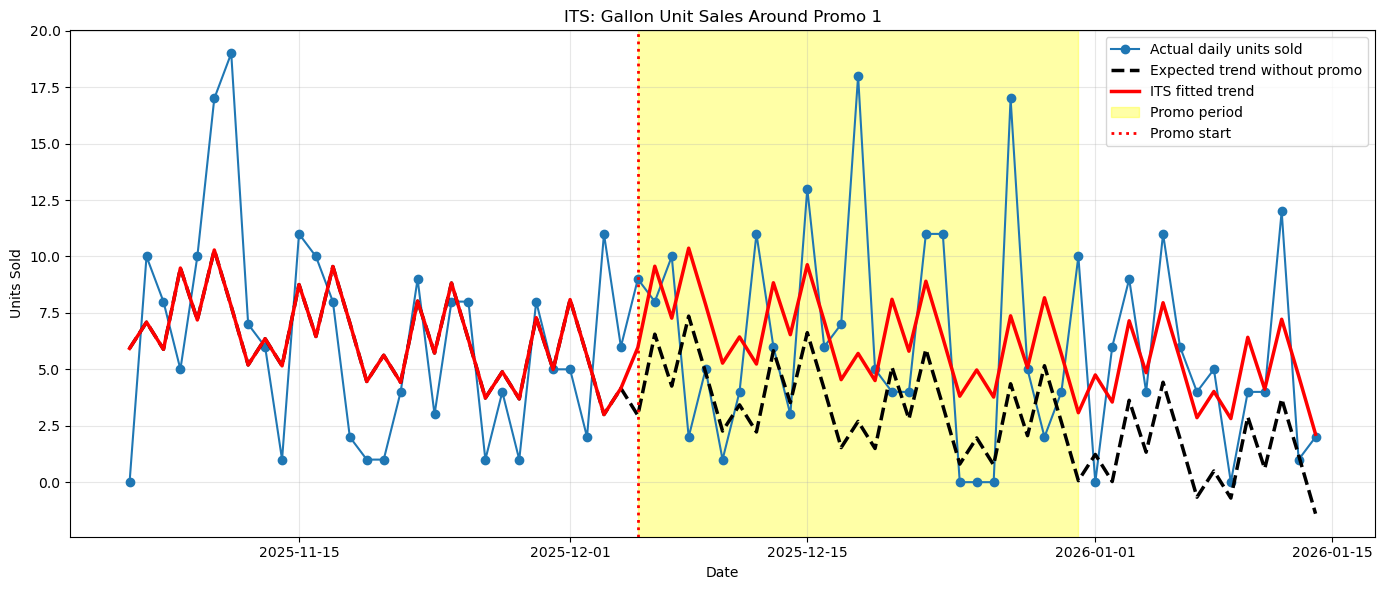


ITS: Gallon Unit Sales Around Promo 1
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       6.0965      1.756      3.471      0.001       2.585       9.608
C(day_of_week)[T.Monday]        4.7139      1.983      2.378      0.021       0.749       8.678
C(day_of_week)[T.Saturday]      3.7046      1.973      1.878      0.065      -0.240       7.649
C(day_of_week)[T.Sunday]        1.5093      1.976      0.764      0.448      -2.443       5.461
C(day_of_week)[T.Thursday]      1.0964      1.979      0.554      0.582      -2.861       5.054
C(day_of_week)[T.Tuesday]       2.3185      1.991      1.164      0.249      -1.663       6.300
C(day_of_week)[T.Wednesday]    -0.1695      1.942     -0.087      0.931      -4.053       3.713
time                           -0.1046      0.070     -1.500      0.139      -0.244       0.035
i

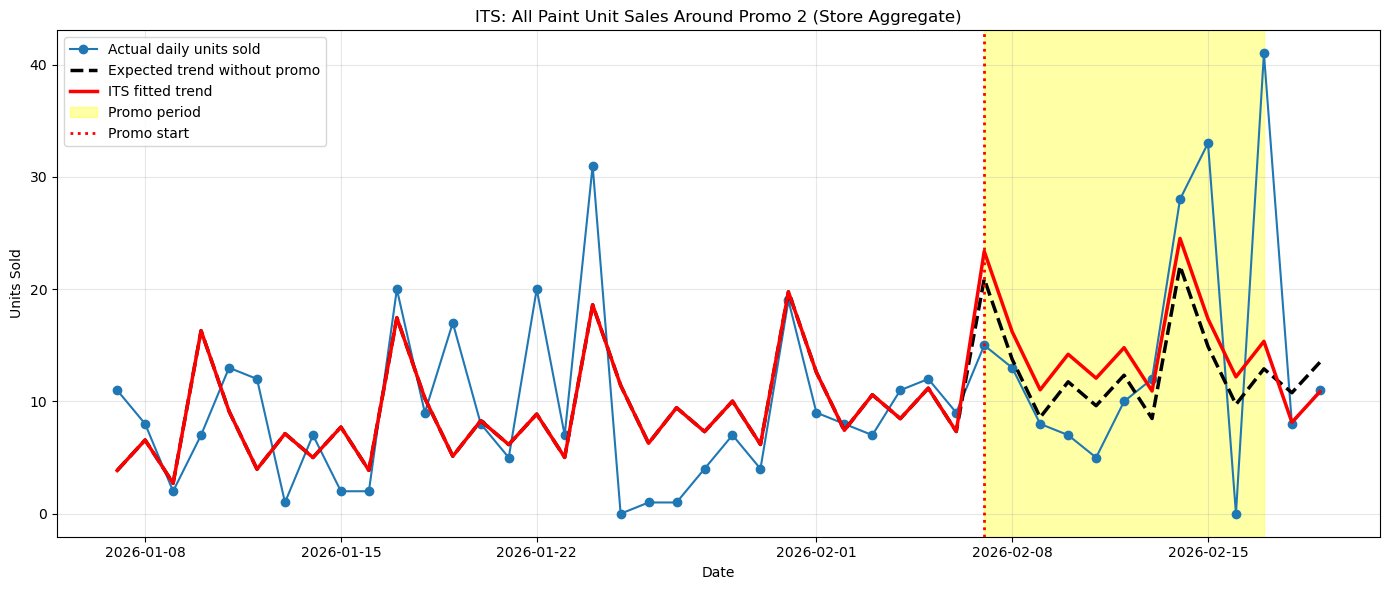


ITS: All Paint Unit Sales Around Promo 2
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -1.5346      1.070     -1.434      0.154      -3.648       0.579
C(Size)[T.Gallon]               4.7879      0.876      5.464      0.000       3.057       6.518
C(Size)[T.Half Pint]            2.2424      0.876      2.559      0.011       0.512       3.973
C(Size)[T.Quart]                1.4848      0.876      1.695      0.092      -0.246       3.215
C(day_of_week)[T.Monday]        0.1908      1.033      0.185      0.854      -1.849       2.231
C(day_of_week)[T.Saturday]      3.3566      1.037      3.238      0.001       1.309       5.404
C(day_of_week)[T.Sunday]        1.5237      1.034      1.473      0.143      -0.519       3.566
C(day_of_week)[T.Thursday]      1.0055      1.010      0.996      0.321      -0.988       2.99

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = pd.read_csv("../data/feature_engineered_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Promo windows
PROMO_1_START = pd.Timestamp("2025-12-05")
PROMO_1_END = pd.Timestamp("2025-12-31")

PROMO_2_START = pd.Timestamp("2026-02-07")
PROMO_2_END = pd.Timestamp("2026-02-17")


def run_its_plot(data, title, window_start, window_end, promo_start, promo_end):
    """
    Interrupted Time Series: 
    Automatically adjusts logic for Single-Size vs. Multi-Size datasets.

    """
    data = data.copy()
    sizes = data["Size"].dropna().unique()
    multiple_sizes = len(sizes) > 1

    # Base grouping - explicitly handle multi-index for filling zeros
    daily = (
        data.groupby(["Date", "Size"])["Quantity"]
        .sum()
        .reset_index()
    )
    
    all_dates = pd.date_range(window_start, window_end, freq="D")
    # Generates a grid of every possible combination of those dates and product sizes. 
    # This ensures that even if a specific size had 0 sales on a given day, that day still exists in the dataset.
    full_index = pd.MultiIndex.from_product(
        [all_dates, sizes],
        names=["Date", "Size"]
    )
    
    # Forces the aggregated daily sales data to fit into the complete grid
    daily = (
        daily.set_index(["Date", "Size"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    # Keep local window
    daily = daily[
        (daily["Date"] >= window_start) &
        (daily["Date"] <= window_end)
    ].copy()

    # Standard ITS variables
    daily["time"] = (daily["Date"] - daily["Date"].min()).dt.days
    daily["day_of_week"] = daily["Date"].dt.day_name()
    daily["is_promo"] = ((daily["Date"] >= promo_start) & (daily["Date"] <= promo_end)).astype(int)
    daily["is_post_promo"] = (daily["Date"] > promo_end).astype(int)

    # Smart Regression Formula Logic
    if multiple_sizes:
        # Create explicit promo columns for each size to get clean coefficients
        promo_cols = []
        for size in sizes:
            clean_name = size.replace(" ", "_")
            col_name = f"promo_{clean_name}"
            # 1 if in promo window AND is this specific size
            daily[col_name] = ((daily["is_promo"] == 1) & (daily["Size"] == size)).astype(int)
            promo_cols.append(col_name)
            
        formula = f"Quantity ~ time + C(Size) + is_post_promo + C(day_of_week) + {' + '.join(promo_cols)}"
    else:
        formula = "Quantity ~ time + is_promo + is_post_promo + C(day_of_week)"

    # Fit the model
    model = smf.ols(formula, data=daily).fit()

    # Smart Predictions & Counterfactual
    daily["fitted_its"] = model.predict(daily)
    
    counterfactual = daily.copy()
    counterfactual["is_promo"] = 0
    counterfactual["is_post_promo"] = 0
    if multiple_sizes:
        for col in promo_cols:
            counterfactual[col] = 0
            
    daily["counterfactual_no_promo"] = model.predict(counterfactual)
    daily["incremental_units"] = daily["Quantity"] - daily["counterfactual_no_promo"]

    # Plotting (Aggregate if multiple sizes to prevent graph scribbles)
    if multiple_sizes:
        plot_df = daily.groupby("Date")[["Quantity", "counterfactual_no_promo", "fitted_its"]].sum().reset_index()
        plot_title = title + " (Store Aggregate)"
    else:
        plot_df = daily.copy()
        plot_title = title

    plt.figure(figsize=(14, 6))
    plt.plot(plot_df["Date"], plot_df["Quantity"], marker="o", linewidth=1.5, label="Actual daily units sold")
    plt.plot(plot_df["Date"], plot_df["counterfactual_no_promo"], linestyle="--", linewidth=2.5, color="black", label="Expected trend without promo")
    plt.plot(plot_df["Date"], plot_df["fitted_its"], linewidth=2.5, color="red", label="ITS fitted trend")
    plt.axvspan(promo_start, promo_end, color="yellow", alpha=0.35, label="Promo period")
    plt.axvline(promo_start, color="red", linestyle=":", linewidth=2, label="Promo start")
    plt.title(plot_title)
    plt.xlabel("Date")
    plt.ylabel("Units Sold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print Output
    print("\n" + "="*60)
    print(title)
    print("="*60)
    print(model.summary().tables[1])

    print("\nInterpretation:")
    print(f"Pre-promo daily trend slope: {model.params['time']:.3f} units/day")
    print(f"Post-promo cannibalization dip: {model.params['is_post_promo']:.3f} units")
    
    print("\nExpected Baselines & Lifts (Average per day during promo window):")
    
    # Filter to only the days the promo was active
    promo_window_df = daily[daily["is_promo"] == 1]

    summary_data = []

    if multiple_sizes:
        baseline_by_size = promo_window_df.groupby("Size")["counterfactual_no_promo"].mean()
        
        for size in sizes:
            clean_name = size.replace(" ", "_")
            col_name = f"promo_{clean_name}"
            
            baseline = baseline_by_size.get(size, 0)
            lift = model.params.get(col_name, 0)
            
            print(f"  {size}:")
            print(f"    Expected Baseline: {baseline:.3f} units/day")
            print(f"    Promo Lift:       +{lift:.3f} units/day")
            
            # Save to our list
            summary_data.append({
                "Size": size,
                "Expected_Daily_Baseline": baseline,
                "Daily_Promo_Lift": lift
            })
    else:
        baseline = promo_window_df["counterfactual_no_promo"].mean()
        lift = model.params.get('is_promo', 0)
        
        print(f"  Gallon:")
        print(f"    Expected Baseline: {baseline:.3f} units/day")
        print(f"    Promo Lift:       +{lift:.3f} units/day")
        
        # Save to our list
        summary_data.append({
            "Size": "Gallon",
            "Expected_Daily_Baseline": baseline,
            "Daily_Promo_Lift": lift
        })

    # Convert the list into a clean DataFrame
    summary_df = pd.DataFrame(summary_data)

    # Return the summary_df as the third output
    return daily, model, summary_df

# Graph 1: Promo 1, Gallons only

gallons_only = df[df["Size"] == "Gallon"].copy()

promo1_daily, promo1_model, promo1_summary = run_its_plot(
    data=gallons_only,
    title="ITS: Gallon Unit Sales Around Promo 1",
    window_start=pd.Timestamp("2025-11-05"),
    window_end=pd.Timestamp("2026-01-14"),
    promo_start=PROMO_1_START,
    promo_end=PROMO_1_END
)

# Graph 2: Promo 2, All paint

paint_sizes = ["Gallon", "5 Gallon", "Quart", "Half Pint"]
all_paint = df[df["Size"].isin(paint_sizes)].copy()

promo2_daily, promo2_model, promo2_summary = run_its_plot(
    data=all_paint,
    title="ITS: All Paint Unit Sales Around Promo 2",
    window_start=pd.Timestamp("2026-01-07"),
    window_end=pd.Timestamp("2026-02-19"), 
    promo_start=PROMO_2_START,
    promo_end=PROMO_2_END
)

# Save ITS outputs for Notebook 3
promo1_daily.to_csv("../data/promo1_its_daily.csv", index=False)
promo2_daily.to_csv("../data/promo2_its_daily.csv", index=False)

# Save the exact Baselines and Lifts for Profit & Elasticity calculations
promo1_summary.to_csv("../data/promo1_baselines_and_lifts.csv", index=False)
promo2_summary.to_csv("../data/promo2_baselines_and_lifts.csv", index=False)

promo1_model.conf_int().to_csv("../data/promo1_its_ci.csv", header=["lower", "upper"])
promo2_model.conf_int().to_csv("../data/promo2_its_ci.csv", header=["lower", "upper"])

The ITS model fits a regression that controls for the day-of-week structure, the underlying time trend, and the post-promo period, then isolates a lift coefficient that is specific to the promotion window. The chart for each promo shows three lines: actual daily sales, the ITS fitted line which is what the model says happened including the promotion effect, and the dashed counterfactual which is what the model estimates would have happened without the promotion. The gap between actual and the dashed counterfactual during the yellow window is the incremental lift estimate. 

---

Promo 1 — Gallon Unit Sales, December 5 to December 31, 2025

This is a simpler single-size regression looking only at gallon sales. The analysis window covers one month before the promo through two weeks after it ended, giving the model enough pre-promo data to estimate the baseline trend and enough post-promo data to look for cannibalization.

Intercept: This is the model's estimated baseline daily gallon sales on the reference day of the week — Friday is the omitted category in the day-of-week dummies — at day zero of the analysis window when no promo is active. The p-value of 0.001 and a CI that stays well above zero confirm this is highly significant. On a typical Friday at the start of the window, the model expects around 6 gallons sold per day as a starting point.

C(day_of_week)[T.Monday]: Monday adds about 4.7 additional gallon units above the Friday baseline. This is statistically significant and the CI does not cross zero. It makes intuitive sense — contractors tend to pick up supplies at the start of the week before heading to job sites.

C(day_of_week)[T.Saturday]: Saturday adds about 3.7 units. The p-value of 0.065 is borderline and the CI barely clips below zero. This is suggestive of a weekend retail customer effect but not conclusive.

C(day_of_week)[T.Sunday]: A modest positive estimate but the wide CI crosses zero and p = 0.448. Indistinguishable from noise — Sunday looks the same as Friday.

C(day_of_week)[T.Thursday], C(day_of_week)[T.Tuesday], C(day_of_week)[T.Wednesday]. None of these midweek days show a statistically meaningful difference from Friday. The model includes them as controls regardless to prevent any day-of-week pattern from bleeding into the promo estimate.

time: This is the pre-existing daily trend in gallon sales across the window. The negative coefficient means the model estimates that on a non-promo trajectory, gallon sales were declining by about 0.1 units for every additional day. The direction makes sense as December is a slow period for paint and sales trend downward toward the holiday shutdown. However p = 0.139 and the CI crosses zero, so I cannot statistically confirm this is a real trend rather than noise. The model still controls for it because even an uncertain slope control is better than assuming sales would have been flat heading into December.

is_promo: This is the key estimate for Promo 1. The model says the promotion added 3.01 gallon units per day above what the pre-existing trend alone would have produced. However p = 0.197 is above the 0.05 threshold and the CI runs from -1.6 to +7.6, meaning a zero effect or even a small negative effect cannot be ruled out. The standard error of 2.31 is nearly as large as the coefficient itself. The best guess is +3, but with enough uncertainty that the true effect could plausibly be anywhere from slightly negative to more than double that estimate. To put it another way: if the promotion had zero actual effect, I would still expect to observe a t-statistic of 1.3 or larger about 20% of the time just from random day-to-day variation. That does not make the estimate useless, but it does mean I cannot make a high-confidence claim on it.

is_post_promo: This was designed to detect cannibalization, a dip in sales after the promo ends, which would indicate customers pulled forward purchases they would have made in January anyway. A negative coefficient would signal cannibalization. Instead the estimate is positive, which is the opposite of cannibalization, and with p = 0.346 and a CI spanning from nearly -4 to +11 it is completely uninformative. The post-promo window for Promo 1 runs into January, which is a naturally recovering month that introduces competing signals the model cannot separate from any cannibalization effect.

Baseline and lift for Promo 1. The expected daily baseline without the promo is 3.51 gallons per day. The estimated lift is +3.01 gallons per day, implying the promotion may have roughly doubled daily gallon sales in December. But the 95% CI on that lift spans from -1.6 to +7.6, so the range of plausible outcomes is wide. I carry the point estimate of +3.01 forward as the best available number.

---

Promo 2 — All Paint Unit Sales, February 7 to February 17, 2026

The Promo 2 model is more complex because it covers all four paint sizes simultaneously. Instead of a single is_promo flag, the model uses separate promo terms for each size so each size gets its own independent lift estimate.

Intercept: The intercept represents 5 Gallon, the reference size since it has the lowest average volume — on Friday, at day zero with no promo. A slightly negative intercept does not mean the model predicts negative sales. It just reflects how the baseline for a low-selling size on a typical day anchors the regression when all other variables are zeroed out. Not statistically significant.

C(Size)[T.Gallon]: Gallons sell about 4.8 more units per day than 5 Gallons on average. p is essentially zero and the CI is well above zero. This captures the structural difference in demand between sizes and confirms gallons are the dominant product.

C(Size)[T.Half Pint]: Half Pints sell about 2.2 more per day than 5 Gallons. Statistically significant.

C(Size)[T.Quart]: Quarts sell about 1.5 more per day than 5 Gallons. Borderline, as CI just clips below zero.

C(day_of_week)[T.Monday]: No meaningful Monday pattern across all sizes in February. The contractor Monday stocking effect that appeared in Promo 1 does not show up when all sizes are pooled together.

C(day_of_week)[T.Saturday]: Saturday adds about 3.4 units across all sizes. Highly significant. This is the clearest day-of-week signal in the Promo 2 model and aligns with the retail customer weekend buying pattern seen in the day-of-week charts above.

C(day_of_week)[T.Sunday] Positive direction but not significant. C(day_of_week)[T.Thursday], C(day_of_week)[T.Tuesday], C(day_of_week)[T.Wednesday]: none of these weekdays are meaningfully different from Friday. All included as controls.

time: A small positive trend; sales were growing slightly heading into February at about 0.04 additional units per day. Not statistically significant since the CI crosses zero, but the positive direction is notable because it contrasts with the declining December trend from Promo 1. January into February is typically when painting activity picks back up after winter, and this coefficient is picking that up.

is_post_promo: The slight negative coefficient for Promo 2 points directionally toward a mild cannibalization effect, fewer sales than expected in the days after the promo ended. However p = 0.697 and the CI spans from -4 to +2.7. With the data cutting off only a couple of weeks after Promo 2 ended, the model has very little post-promo information to work with and this estimate is essentially noise. Combined with the opposite positive post-promo estimate from Promo 1, there is no consistent cannibalization pattern I can rely on, which is why it is excluded from notebook 3.

promo_Gallon: This is the strongest and clearest result in the entire analysis. The February promotion added an estimated 4.32 additional gallon units per day above the counterfactual baseline. p = 0.003 is well below the 0.05 threshold and the confidence interval stays entirely above zero with a lower bound of +1.45. This is statistically significant. The width of the CI (about 5.7 units from lower to upper) still reflects uncertainty about the exact magnitude, but the direction and existence of the effect are not in question.

promo_Half_Pint: Half Pint sales appear to have slightly dipped during the promo relative to the model's expectation. However p = 0.223 and the CI spans from -4.6 to +1.1. Not significant. Half Pint buyers are typically picking up specific colour samples for a project and are not as price-sensitive at that quantity. A broad discount is unlikely to meaningfully stimulate that demand. I treat this as a zero lift. Note that no Half Pint sales were made using the discount, this Half Pint "lift" is purely what is happening during this promo time frame, but no Half Pint were bought using the promo discount.

promo_Quart: A small positive estimate for Quarts but p = 0.624 with a CI crossing zero by a wide margin. Not meaningful.

promo_5_Gallon: Slightly negative but not significant. The 5 Gallon base rate averages just 1.2 units per day, so even small random fluctuations produce large-looking coefficients relative to the baseline. There are simply not enough 5 Gallon sales events in a short promo window to say anything reliable. Note that like Half Pint, there were no 5 Gallon sales made using the promo discount.

Baseline and lift for Promo 2. Gallon: baseline 5.955 units/day, lift +4.318 units/day, statistically significant. Half Pint: baseline 3.409 units/day, lift -1.773, not significant, treated as zero. Quart: baseline 2.652 units/day, lift +0.712, not significant, treated as zero. 5 Gallon: baseline 1.167 units/day, lift -0.803, not significant, treated as zero. Only the gallon lift from Promo 2 is carried forward as a confident estimate.


Why I am proceeding despite the mixed statistical picture

Statistical significance and business usefulness are not the same thing. The p < 0.05 threshold is a rule of thumb developed in contexts with large sample sizes and clean experimental designs. The situation here is genuinely difficult: both promotions ran for less than five weeks, the full dataset covers less than nine months, and daily paint sales are noisy because a single large contractor order can shift the numbers significantly on any given day. With roughly 30 data points per promo window, high day-to-day variance, no control group, and no ability to randomize who received the promotion, finding p < 0.05 across all coefficients is hard even if the promotions had very real effects.

The way I handle this uncertainty in practice is by carrying the confidence intervals forward alongside the point estimates. Notebook 3 uses the point estimate for the expected-case profit calculation and the confidence interval bounds for optimistic and pessimistic scenarios. This gives the business not just the most likely outcome but also the range of plausible outcomes given how much noise is in the data. That is a more honest and useful output than either ignoring the lift estimates or pretending they are known more precisely than they are. The baselines, lifts, and confidence intervals are all saved to CSV at the bottom of the ITS cell and feed directly into notebook 3. Furthermore, this is intended to be a learning experience and also to create a prototype that can be scaled once more data becomes available.